### 📊 Customer Segmentation using RFM Analysis

This analytical model segments Olist's customer base into distinct behavioral groups based on three key transactional metrics:

* **Recency (R):** How many days have passed since the customer's last purchase? (Measures freshness of customer engagement).
* **Frequency (F):** How many distinct orders has the customer placed? (Measures customer loyalty and purchasing habits).
* **Monetary (M):** What is the total amount of money the customer has spent on the platform? (Measures total customer lifetime value and financial contribution).

✅ Successfully calculated and saved main.analytics_rfm table!


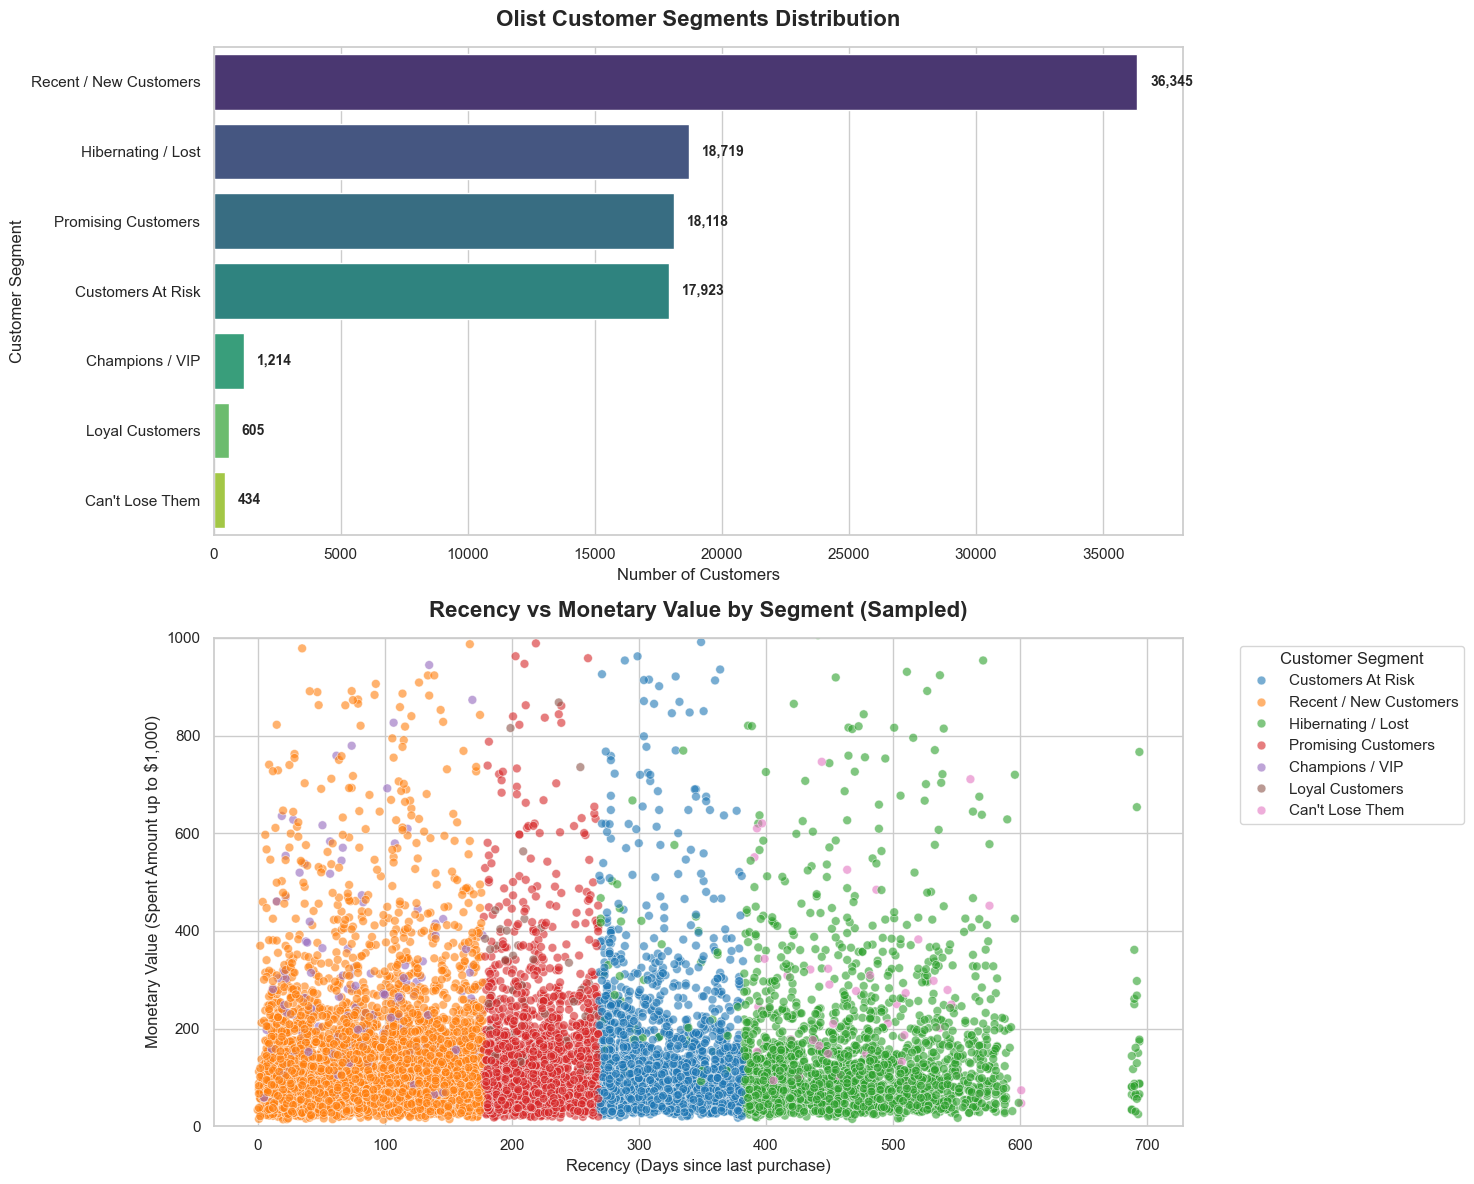

✅ Successfully exported charts to 'rfm_segmentation_analysis.png'!


<Figure size 640x480 with 0 Axes>

In [5]:
import duckdb
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CALCULATE RAW RFM METRICS
# ==========================================
db_path = "/Users/ciaranguyen/Documents/ecom_project/dev.duckdb"
con = duckdb.connect(db_path)

rfm_query = """
    WITH customer_orders AS (
        SELECT 
            c.customer_unique_id,
            m.order_id,
            m.purchase_at,
            m.total_amount_paid
        FROM main.marts m
        JOIN read_csv_auto('data/raw/olist_customers_dataset.csv') c 
            ON m.customer_id = c.customer_id
        WHERE m.order_status = 'delivered'
    ),
    
    rfm_base AS (
        SELECT
            customer_unique_id,
            DATE_DIFF('day', MAX(purchase_at), (SELECT MAX(purchase_at) FROM customer_orders)) as recency,
            COUNT(DISTINCT order_id) as frequency,
            SUM(total_amount_paid) as monetary
        FROM customer_orders
        GROUP BY customer_unique_id
    )
    
    SELECT * FROM rfm_base
"""

df_rfm = con.execute(rfm_query).df()
con.close()

# ==========================================
# 2. RFM SCORING & SEGMENTATION
# ==========================================
# Score metrics from 1 to 5
df_rfm['R_score'] = pd.qcut(df_rfm['recency'], 5, labels=[5, 4, 3, 2, 1])
df_rfm['M_score'] = pd.qcut(df_rfm['monetary'], 5, labels=[1, 2, 3, 4, 5])
# Custom logic for Frequency since most customers only purchase once
df_rfm['F_score'] = df_rfm['frequency'].apply(lambda x: 1 if x == 1 else (2 if x == 2 else 3))

# Combine scores into an RFM Score string
df_rfm['RFM_Score'] = df_rfm['R_score'].astype(str) + df_rfm['F_score'].astype(str) + df_rfm['M_score'].astype(str)

# Define segmentation logic based on R and F scores
def segment_customer(df):
    r = int(df['R_score'])
    f = int(df['F_score'])
    
    if (r >= 4) and (f >= 2):
        return 'Champions / VIP'
    elif (r >= 3) and (f >= 2):
        return 'Loyal Customers'
    elif (r >= 4) and (f == 1):
        return 'Recent / New Customers'
    elif (r == 3) and (f == 1):
        return 'Promising Customers'
    elif (r == 2) and (f == 1):
        return 'Customers At Risk'
    elif (r == 1) and (f >= 2):
        return 'Can\'t Lose Them'
    else:
        return 'Hibernating / Lost'

df_rfm['Segment'] = df_rfm.apply(segment_customer, axis=1)

# Save the analytical results back to DuckDB
con = duckdb.connect(db_path)
con.execute("CREATE OR REPLACE TABLE main.analytics_rfm AS SELECT * FROM df_rfm")
con.close()
print("✅ Successfully calculated and saved main.analytics_rfm table!")

# ==========================================
# 3. DATA VISUALIZATION
# ==========================================
# Set chart style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

# --- CHART 1: Customer Segments Distribution (Bar Chart) ---
plt.subplot(2, 1, 1)
segment_counts = df_rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Customer Count']

sns.barplot(
    data=segment_counts, 
    y='Segment', 
    x='Customer Count', 
    hue='Segment',
    palette='viridis', 
    legend=False
)
plt.title('Olist Customer Segments Distribution', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Customer Segment', fontsize=12)

# Add value labels to the bars
for index, row in segment_counts.iterrows():
    plt.text(row['Customer Count'] + 500, index, f"{row['Customer Count']:,}", va='center', fontsize=10, fontweight='bold')

# --- CHART 2: Recency vs Monetary Relationship (Scatter Plot) ---
plt.subplot(2, 1, 2)
# Sample 10,000 customers for smoother rendering if dataset is too large
df_sample = df_rfm.sample(n=min(10000, len(df_rfm)), random_state=42)

sns.scatterplot(
    data=df_sample, 
    x='recency', 
    y='monetary', 
    hue='Segment', 
    palette='tab10', 
    alpha=0.6,
    s=40
)
# Limit Y-axis to 1000 to avoid extreme outliers distorting the visualization
plt.ylim(0, 1000) 
plt.title('Recency vs Monetary Value by Segment (Sampled)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Recency (Days since last purchase)', fontsize=12)
plt.ylabel('Monetary Value (Spent Amount up to $1,000)', fontsize=12)
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

plt.savefig('rfm_analytics.png', bbox_inches='tight', dpi=300)
print("✅ Successfully exported charts to 'rfm_segmentation_analysis.png'!")
plt.show()

### 📈 RFM Segmentation - Analytical Insights & Business Conclusions

Based on the generated RFM distribution and relationship plots, we can draw the following strategic conclusions regarding Olist's business model and customer behavioral patterns:

#### 1. The "One-Time Purchaser" Challenge (Acquisition vs. Retention)
* **Insight:** The **Recent / New Customers** group is by far the largest segment with **36,345 customers**, while **Champions / VIP** (1,214) and **Loyal Customers** (605) represent a tiny fraction of the user base.
* **Conclusion:** Olist has an exceptional marketing engine for user acquisition. However, the extreme drop-off between new customers and loyal customers indicates a classic e-commerce retention problem. Most users try the platform once and do not return.

#### 2. High Concentration of At-Risk Revenue
* **Insight:** Over **36,000 customers** fall into the **Hibernating / Lost** (18,719) and **Customers At Risk** (17,923) categories.
* **Conclusion:** These users haven't made a purchase in a long time (ranging from 300 to over 600 days, as shown in the scatter plot). The platform is sitting on a massive graveyard of inactive users who already know the brand but have churned.

#### 3. Strategic Recommendations for the Business
* **Implement Win-Back Campaigns:** Target the *Customers At Risk* segment with personalized email marketing and aggressive discount coupons before they transition fully into *Hibernating*.
* **VIP Perks:** Protect the *Champions / VIP* group. Since they contribute the highest monetary value, they should be enrolled in a loyalty program (e.g., free shipping or priority customer service) to maintain their high lifetime value.

---
*Note: The generated charts have been successfully exported to `rfm_segmentation_analysis.png` for reporting.*

## Cohort Retention Analysis (Monthly))

✅ Successfully calculated and saved main.analytics_cohort table!
✅ Successfully exported charts to 'cohort_retention_analysis.png'!


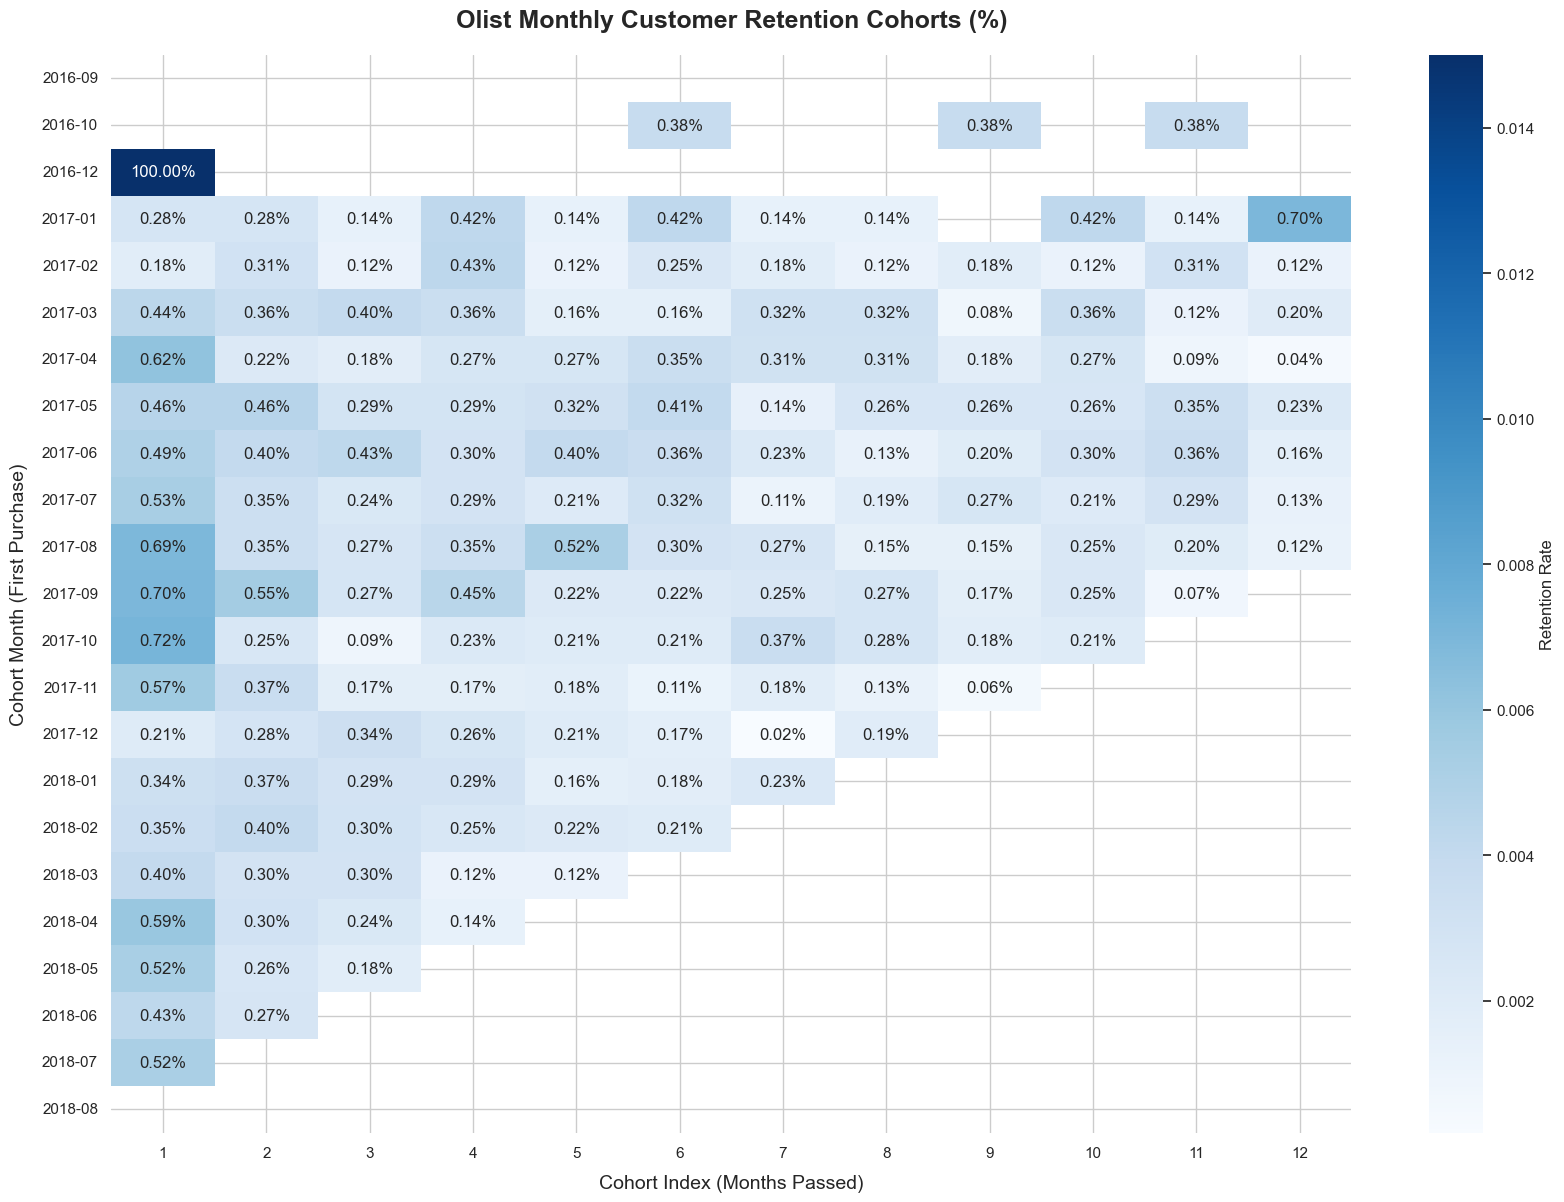

In [7]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. RETRIEVE DATA & CALCULATE COHORTS
# ==========================================
db_path = "/Users/ciaranguyen/Documents/ecom_project/dev.duckdb"
con = duckdb.connect(db_path)

cohort_query = """
    WITH customer_orders AS (
        SELECT 
            c.customer_unique_id,
            m.order_id,
            m.purchase_at
        FROM main.marts m
        JOIN read_csv_auto('data/raw/olist_customers_dataset.csv') c 
            ON m.customer_id = c.customer_id
        WHERE m.order_status = 'delivered'
    ),
    
    first_purchase AS (
        SELECT 
            customer_unique_id,
            MIN(purchase_at) as first_purchase_date
        FROM customer_orders
        GROUP BY customer_unique_id
    ),
    
    cohort_base AS (
        SELECT
            co.customer_unique_id,
            co.order_id,
            -- Trích xuất tháng/năm của lần mua đầu tiên (Cohort Month)
            DATE_TRUNC('month', fp.first_purchase_date)::DATE as cohort_month,
            -- Trích xuất tháng/năm của đơn hàng hiện tại
            DATE_TRUNC('month', co.purchase_at)::DATE as order_month,
            -- Tính khoảng cách số tháng giữa lần mua hiện tại và lần đầu tiên
            DATE_DIFF('month', fp.first_purchase_date, co.purchase_at) as cohort_index
        FROM customer_orders co
        JOIN first_purchase fp ON co.customer_unique_id = fp.customer_unique_id
    )
    
    SELECT 
        cohort_month,
        cohort_index,
        COUNT(DISTINCT customer_unique_id) as unique_customers
    FROM cohort_base
    GROUP BY cohort_month, cohort_index
"""

df_cohort = con.execute(cohort_query).df()
con.close()

# ==========================================
# 2. PIVOT DATA & CALCULATE RETENTION RATE
# ==========================================
cohort_pivot = df_cohort.pivot(index='cohort_month', columns='cohort_index', values='unique_customers')

cohort_sizes = cohort_pivot.iloc[:, 0]

retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)

retention_matrix.index = pd.to_datetime(retention_matrix.index).strftime('%Y-%m')

con = duckdb.connect(db_path)
con.execute("CREATE OR REPLACE TABLE main.analytics_cohort AS SELECT * FROM df_cohort")
con.close()
print("✅ Successfully calculated and saved main.analytics_cohort table!")

# ==========================================
# 3. HEATMAP VISUALIZATION
# ==========================================
plt.figure(figsize=(20, 14))
plt.title('Olist Monthly Customer Retention Cohorts (%)', fontsize=18, fontweight='bold', pad=20)

sns.heatmap(
    data=retention_matrix.iloc[:, 1:13], 
    annot=True, 
    fmt='.2%', 
    cmap='Blues', 
    vmax=0.015, 
    cbar_kws={'label': 'Retention Rate'}
)

plt.xlabel('Cohort Index (Months Passed)', fontsize=14, labelpad=10)
plt.ylabel('Cohort Month (First Purchase)', fontsize=14, labelpad=10)

plt.savefig('cohort_retention_analysis.png', bbox_inches='tight', dpi=300)
print("✅ Successfully exported charts to 'cohort_retention_analysis.png'!")

plt.show()

### 📉 Cohort Retention Analysis - Analytical Insights & Conclusions

The Monthly Cohort Retention Heatmap tracking customer repeat-purchase behavior reveals critical structural truths about Olist’s customer loyalty and user engagement:

#### 1. The "Under 1%" Retention Reality
* **Insight:** Across almost all historical monthly cohorts (from early 2017 to mid-2018), the customer retention rate drops dramatically in **Month 1 (the very next month)** to **under 1%** (ranging mostly between 0.20% and 0.70%). 
* **Conclusion:** This mathematically confirms the hypothesis surfaced during our RFM analysis. Olist is fundamentally a **"Transaction-focused"** marketplace rather than a **"Relationship-focused"** one. Customers use the platform as a utility to acquire a specific item and have zero built-in habit or ecosystem-driven incentive to return.

#### 2. Absence of Curve Stabilization (The Leaky Bucket)
* **Insight:** In healthy e-commerce platforms, the retention rate typically drops initially but eventually plateaus/stabilizes (e.g., holding at 3% to 5% permanently for older cohorts). On Olist, the metric continues to bleed out and hovers near zero indefinitely, dropping as low as **0.04% - 0.12%** by Month 12.
* **Conclusion:** Olist suffers from a severe **"Leaky Bucket"** problem. No matter how many tens of thousands of new users marketing successfully acquires every month (as seen by the large initial cohort sizes), the platform cannot retain them. This turns Customer Acquisition Cost (CAC) into a highly expensive operational burden rather than an investment in lifetime value.

#### 3. Data Infrastructure Status
* **Backend Storage:** The formalized metrics and pivot calculations have been successfully structured and saved into `dev.duckdb` as the `main.analytics_cohort` table.
* **Asset Export:** The high-resolution matrix visualization has been exported locally to `cohort_retention_analysis.png` for stakeholder reporting.

In [11]:
import duckdb

con = duckdb.connect("/Users/ciaranguyen/Documents/ecom_project/dev.duckdb")

con.execute("COPY main.marts TO 'marts_data.csv' (HEADER, DELIMITER ',')")
con.execute("COPY main.analytics_rfm TO 'rfm_data.csv' (HEADER, DELIMITER ',')")
con.execute("COPY main.analytics_cohort TO 'cohort_data.csv' (HEADER, DELIMITER ',')")

con.close()
print("✅ Xuất thành công 3 file CSV gọn nhẹ vào thư mục dự án!")

✅ Xuất thành công 3 file CSV gọn nhẹ vào thư mục dự án!
